# Laboratório 6 – Laboratório 8 – Segmentação Morfológica Watershed


*   Leonardo Garcia dos Santos 11202230441
*   Ronaldo Avila de Arruda Junior 11202231908

14 de Abril de 2026


# Introdução

O objetivo deste laboratório é explorar a Segmentação Morfológica usando o algoritmo Watershed. Esse método permite separar objetos ou regiões de interesse na imagem. Na prática, a aplicação envolve os seguintes passos: filtros para a remoção de ruídos, limiarização e, em seguida, a Transformada de Distância combinada com um processo de rotulação. Com essas etapas, o algoritmo consegue identificar as áreas base e traçar os contornos, isolando cada elemento da imagem.

# Procedimentos Experimentais

### 3. Atividades Práticas Experimentais

#### (3.a).  
Elabore um programa para realizar as operações passo a passo da Segmentação
Morfológica WATERSHED, sobre (i) a imagem em grupo dos integrantes da equipe bem
como (ii) na imagem dos avatares, e apresente os resultados que segmente cada pessoa da
imagem e cada avatar respectivamente. Neste programa escolha um ou mais filtros para
a remoção de ruídos antes do processo de limiarização. Elabore uma análise detalhada de
cada passo da segmentação, quanto à Limiarização, à Transformada de Distância, e ao
processo de Rotulação. 

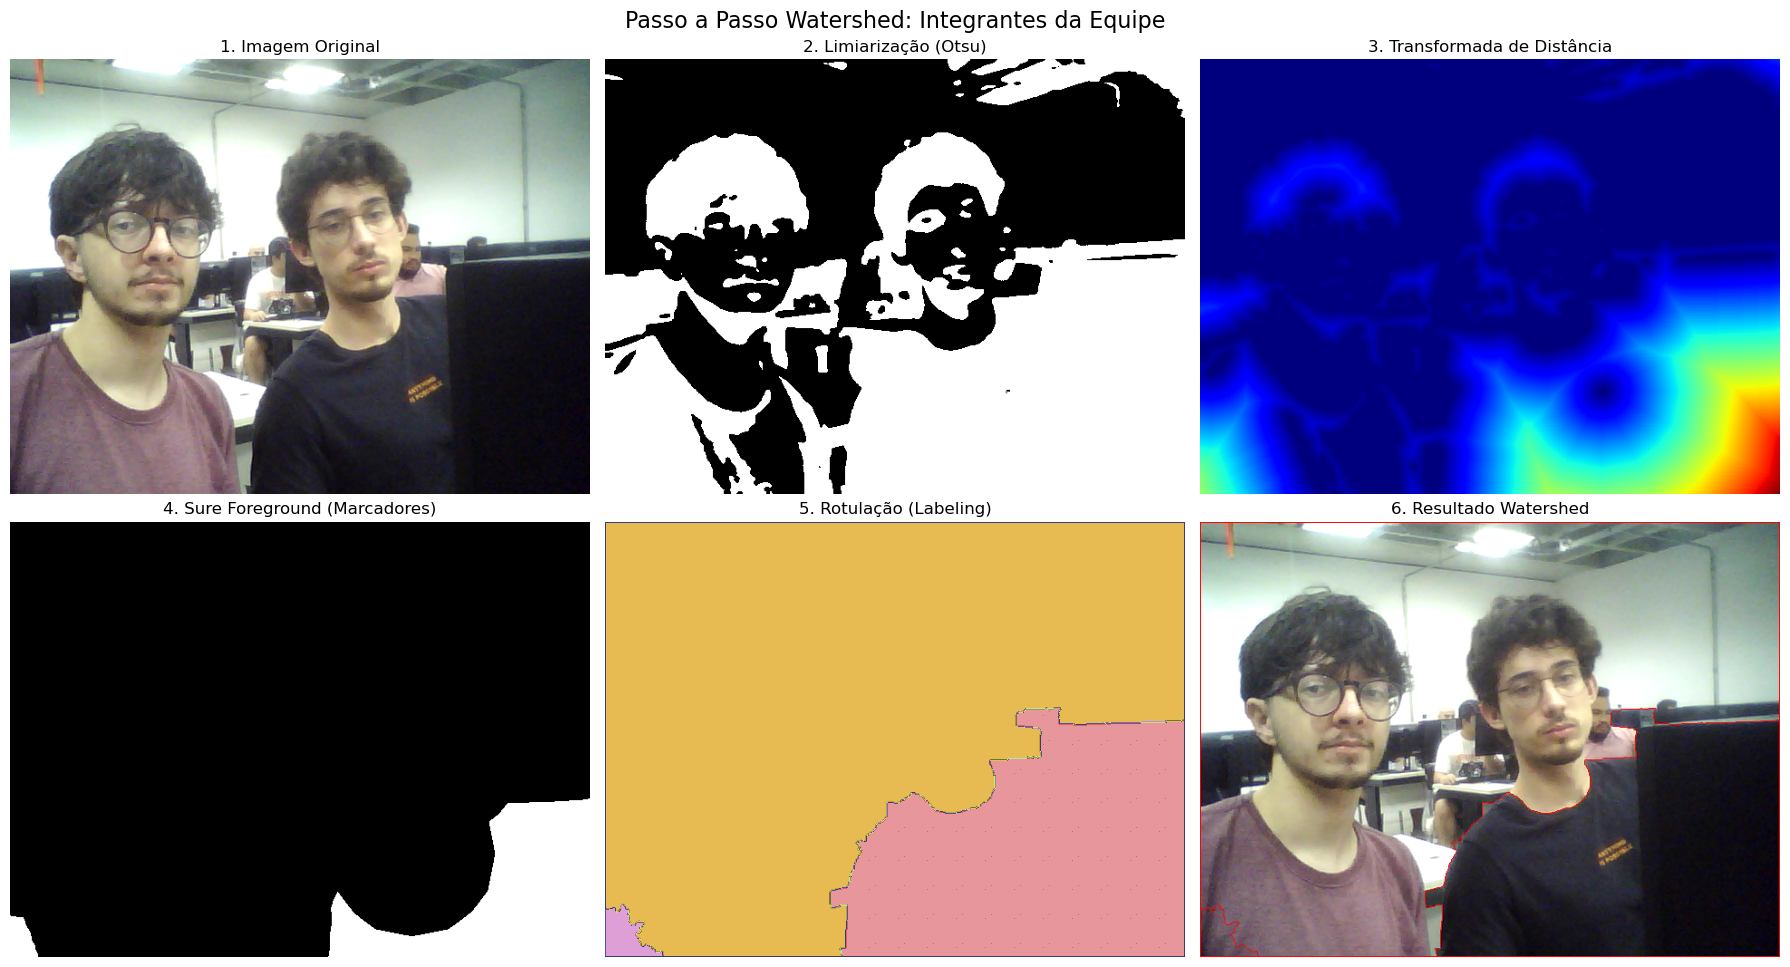

Foram encontrados 2 elementos em Integrantes da Equipe.


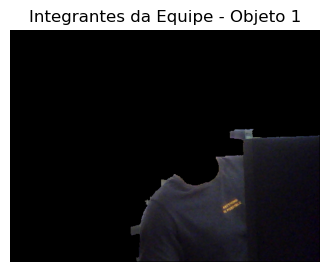

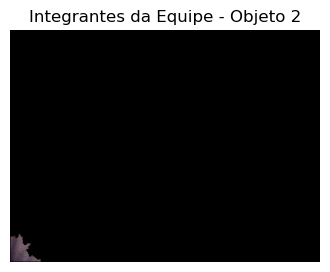

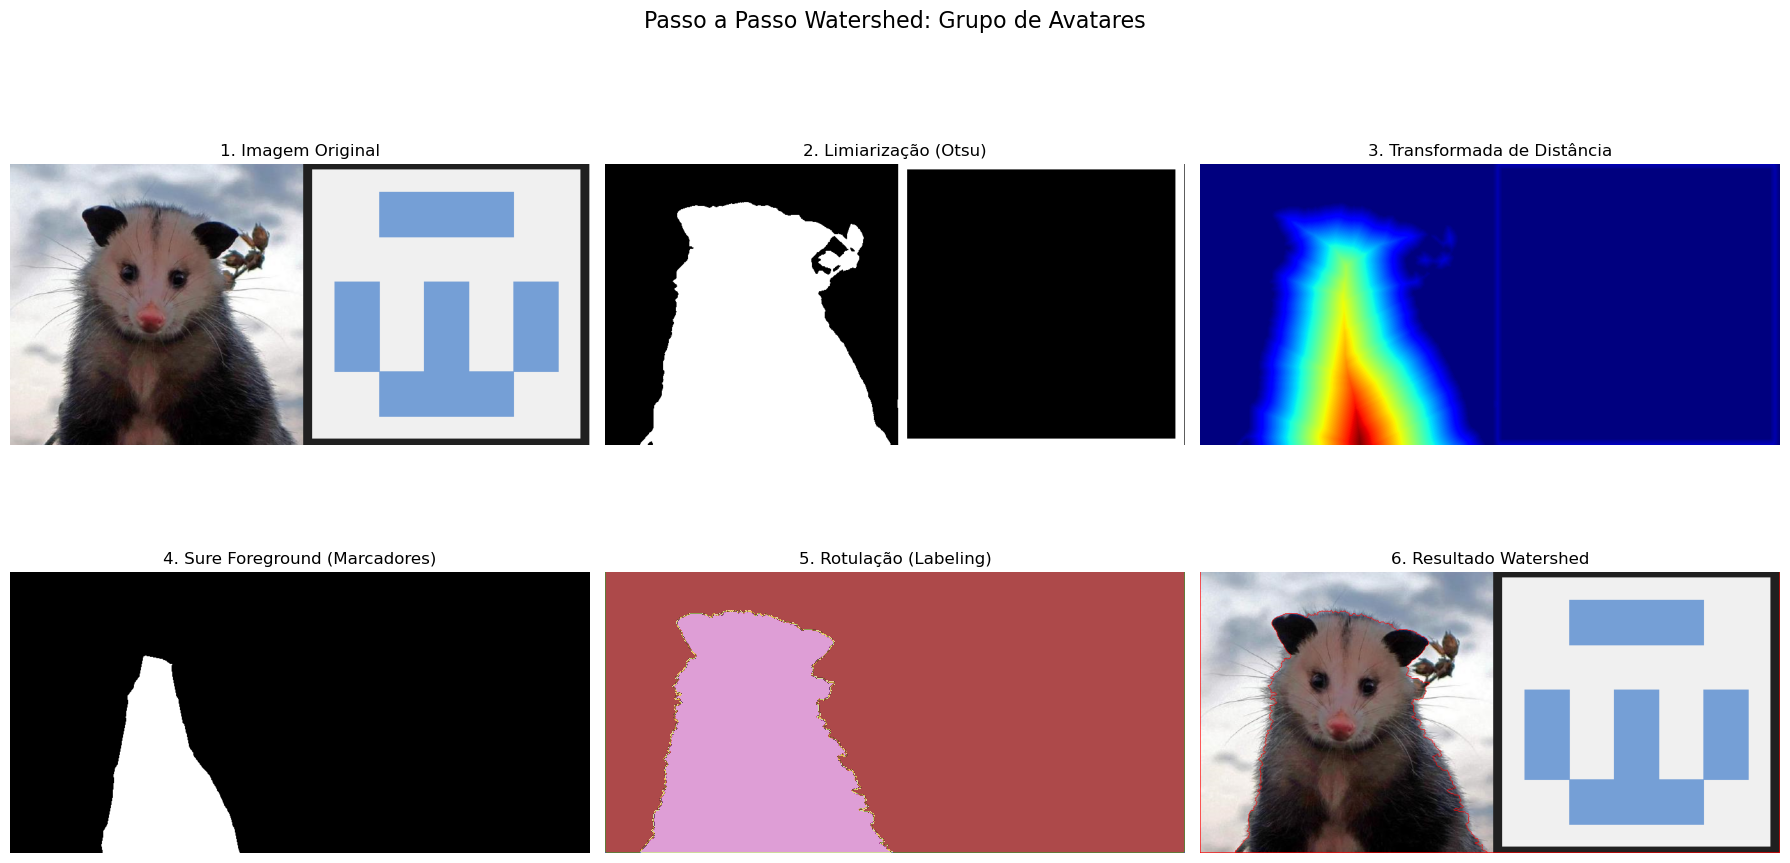

Foram encontrados 1 elementos em Grupo de Avatares.


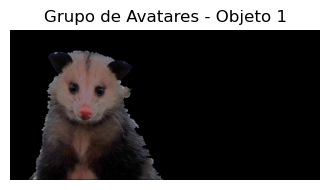

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segmentar_imagem_watershed(caminho_imagem, titulo):
    # 1. Leitura da Imagem
    img = cv2.imread(caminho_imagem)
    if img is None:
        print(f"Erro: Imagem {caminho_imagem} não encontrada.")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Remoção de Ruído (Filtro Bilateral)
    # Escolhido por preservar as bordas enquanto remove o ruído contínuo
    suave = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # 3. Limiarização (Otsu com Inversão)
    # Assumindo que queremos os objetos em branco e o fundo em preto
    ret, thresh = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Operações Morfológicas
    kernel = np.ones((3,3), np.uint8)
    # Opening para remover pequenos ruídos no fundo (falsos positivos)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # Dilatação para encontrar a área que com certeza é fundo 
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # 5. Transformada de Distância 
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # 6. Encontrar região de borda desconhecida
    unknown = cv2.subtract(sure_bg, sure_fg)

    # 7. Processo de Rotulação
    ret, markers = cv2.connectedComponents(sure_fg)
    
    # Adiciona 1 a todos os rótulos para que o fundo certo não seja 0, mas sim 1
    markers = markers + 1
    
    # Marca a região desconhecida com 0
    markers[unknown == 255] = 0

    # 8. Aplicação do Watershed
    markers = cv2.watershed(img, markers)
    
    # Criar imagem final com as bordas em vermelho
    img_final = img_rgb.copy()
    img_final[markers == -1] = [255, 0, 0]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Passo a Passo Watershed: {titulo}', fontsize=16)

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('1. Imagem Original')
    
    axes[0, 1].imshow(thresh, cmap='gray')
    axes[0, 1].set_title('2. Limiarização (Otsu)')
    
    axes[0, 2].imshow(dist_transform, cmap='jet')
    axes[0, 2].set_title('3. Transformada de Distância')
    
    axes[1, 0].imshow(sure_fg, cmap='gray')
    axes[1, 0].set_title('4. Sure Foreground (Marcadores)')
    
    axes[1, 1].imshow(markers, cmap='tab20b')
    axes[1, 1].set_title('5. Rotulação (Labeling)')
    
    axes[1, 2].imshow(img_final)
    axes[1, 2].set_title('6. Resultado Watershed')

    for ax in axes.flatten():
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

    # Mostra cada pessoa/avatar segmentado individualmente
    num_objetos = np.max(markers)
    print(f"Foram encontrados {num_objetos - 1} elementos em {titulo}.")
    
    for i in range(2, num_objetos + 1): # Começa do 2 pois 1 é o fundo
        obj_isolado = np.zeros_like(img_rgb)
        obj_isolado[markers == i] = img_rgb[markers == i]
        
        plt.figure(figsize=(4,4))
        plt.imshow(obj_isolado)
        plt.title(f'{titulo} - Objeto {i-1}')
        plt.axis('off')
        plt.show()

segmentar_imagem_watershed('foto1.png', 'Integrantes da Equipe')
segmentar_imagem_watershed('avatar.png', 'Grupo de Avatares')

#### 3.b).  
Elabore um novo programa para complementar o código anterior tal que a
imagem gerada seja composta pela imagem original, com os contornos das
pessoas/objetos sementadas e rotuladas, e um texto identificando cada
pessoa/objeto segmentada.

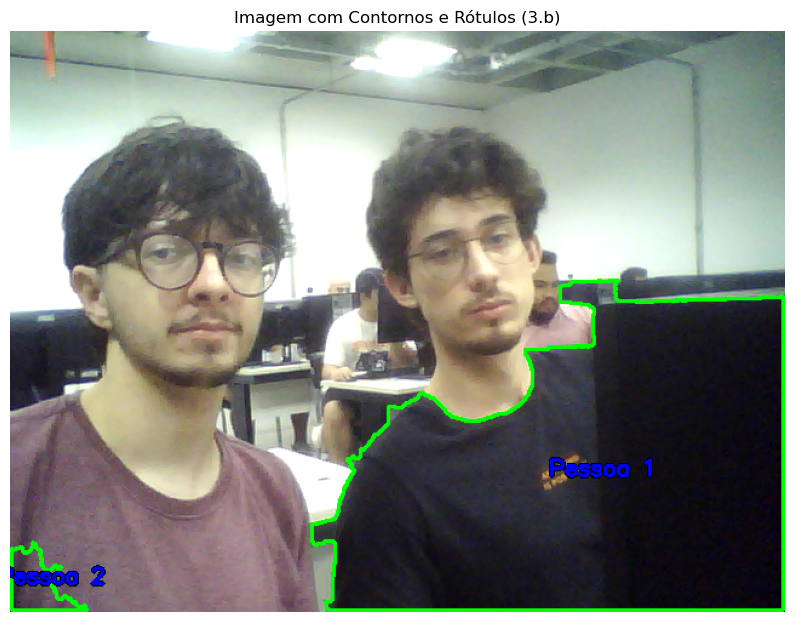

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


nome_arquivo = 'foto1.png' 
img = cv2.imread(nome_arquivo)

if img is None:
    print(f"Erro: Não consegui encontrar a imagem {nome_arquivo}.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Aplicando o Watershed para obter a variável 'markers'
    suave = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    ret, thresh = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    unknown = cv2.subtract(sure_bg, sure_fg)
    ret, markers = cv2.connectedComponents(sure_fg)
    
    markers = markers + 1
    markers[unknown == 255] = 0
    markers = cv2.watershed(img, markers)


    def destacar_objetos_segmentados(img_original, markers, prefixo="Objeto"):
        img_resultado = img_original.copy()
        rotulos = np.unique(markers)
        
        contador = 1
        for rotulo in rotulos:
            if rotulo <= 1: # Ignora fundo e bordas
                continue
                
            mascara = np.zeros_like(markers, dtype=np.uint8)
            mascara[markers == rotulo] = 255
            
            contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contornos:
                maior_contorno = max(contornos, key=cv2.contourArea)
                # Desenha o contorno verde
                cv2.drawContours(img_resultado, [maior_contorno], -1, (0, 255, 0), 2)
                
                # Acha o centro
                M = cv2.moments(maior_contorno)
                if M["m00"] != 0:
                    cX = int(M["m10"] / M["m00"])
                    cY = int(M["m01"] / M["m00"])
                else:
                    cX, cY = 0, 0
                    
                texto = f"{prefixo} {contador}"
                
                # Desenha texto com borda
                cv2.putText(img_resultado, texto, (cX - 30, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
                cv2.putText(img_resultado, texto, (cX - 30, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                
                contador += 1
                
        return img_resultado


    img_final_anotada = destacar_objetos_segmentados(img, markers, prefixo="Pessoa")

    plt.figure(figsize=(10, 8))
    # Convertendo BGR para RGB para o matplotlib exibir as cores corretas
    plt.imshow(cv2.cvtColor(img_final_anotada, cv2.COLOR_BGR2RGB))
    plt.title('Imagem com Contornos e Rótulos (3.b)')
    plt.axis('off')
    plt.show()

### ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:

#### (3.c).  
Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações do programa acima da segmentação morfológica, mostrando na tela em tempo
real a imagem original com sobreposição dos contornos da segmentação obtida e texto de
identificação. Grave um video demonstrativo com os integrantes da equipe todos juntos
utilizando este programa com a webcam. Elabore uma análise detalhada e explique os
artefatos ocorridos.

In [10]:
import cv2
import numpy as np

def processar_frame_watershed(frame):
    # 1. Pré-processamento
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Filtro Bilateral para suavizar ruídos mantendo bordas
    suave = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    
    # Limiarização (Ajuste dependendo da iluminação da sua sala)
    # Nota: Em webcams com fundo muito claro, remova o cv2.THRESH_BINARY_INV
    ret, thresh = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 2. Operações Morfológicas
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    
    # 3. Transformada de Distância e Marcadores
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    unknown = cv2.subtract(sure_bg, sure_fg)
    ret, markers = cv2.connectedComponents(sure_fg)
    
    markers = markers + 1
    markers[unknown == 255] = 0
    
    # 4. Watershed
    markers = cv2.watershed(frame, markers)
    
    # 5. Extração de Contornos e Desenho
    rotulos = np.unique(markers)
    contador = 1
    
    for rotulo in rotulos:
        if rotulo <= 1:
            continue
            
        mascara = np.zeros_like(markers, dtype=np.uint8)
        mascara[markers == rotulo] = 255
        
        contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contornos:
            maior_contorno = max(contornos, key=cv2.contourArea)
            
            # IGNORA ARTEFATOS: Só processa objetos grandes (maior que 500 pixels)
            if cv2.contourArea(maior_contorno) > 500:
                cv2.drawContours(frame, [maior_contorno], -1, (0, 255, 0), 2)
                
                M = cv2.moments(maior_contorno)
                if M["m00"] != 0:
                    cX = int(M["m10"] / M["m00"])
                    cY = int(M["m01"] / M["m00"])
                else:
                    cX, cY = 0, 0
                    
                texto = f"Pessoa {contador}"
                cv2.putText(frame, texto, (cX - 30, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
                cv2.putText(frame, texto, (cX - 30, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                
                contador += 1
                
    return frame


print("Iniciando webcam... Pressione 'q' para sair.")
cap = cv2.VideoCapture(0) # 0 é geralmente a câmera padrão do notebook

# Reduzir a resolução para o Watershed rodar mais rápido
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Erro ao capturar imagem da webcam.")
        break
        
    # Processa o frame atual
    frame_processado = processar_frame_watershed(frame.copy())
    
    # Mostra o resultado numa janela
    cv2.imshow('Segmentacao Watershed (Tempo Real)', frame_processado)
    
    # Aguarda 1 milissegundo pela tecla 'q' para fechar
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Iniciando webcam... Pressione 'q' para sair.


QFontDatabase: Cannot find font directory /home/ufabc/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/.local/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/.local/lib/python3.12/site-package

In [5]:
from IPython.display import IFrame

IFrame(src="https://drive.google.com/file/d/1qwXnw8SyZbzPCqPWNiGDV3gRAs14XsfY/preview", width=700.0, height=500.0)

Ao rodar o Watershed na webcam, a iluminação dinâmica do ambiente acaba gerando alguns artefatos visuais bem claros. É comum notar uma cintilação ou troca constante nas caixas de identificação, que acontece porque a máscara binária varia a cada frame, bagunçando a ordem em que o algoritmo distribui os rótulos. Também rolam problemas de supersegmentação, onde uma única pessoa acaba "fatiada" em várias partes devido a roupas estampadas ou falta de contraste com o fundo, o que cria múltiplos núcleos na transformada de distância. Pelo lado oposto, se a equipe ficar muito espremida na câmera, pode ocorrer a subsegmentação, fundindo a galera em um único rótulo. Além disso, como o método avalia apenas a variação de luz e sombra e não possui nenhum reconhecimento facial inteligente, qualquer objeto do fundo com um contraste mais forte acaba sendo segmentado junto, mesmo que a gente consiga filtrar as sujeiras menores via código.

### 4) Exercícios Propostos

#### (4.a).  
Elabore um programa para aplicar Segmentação Morfológica WATERSHED em
imagens do seu trabalho final, explicando o objetivo deste procedimento dentro do contexto da
aplicação.

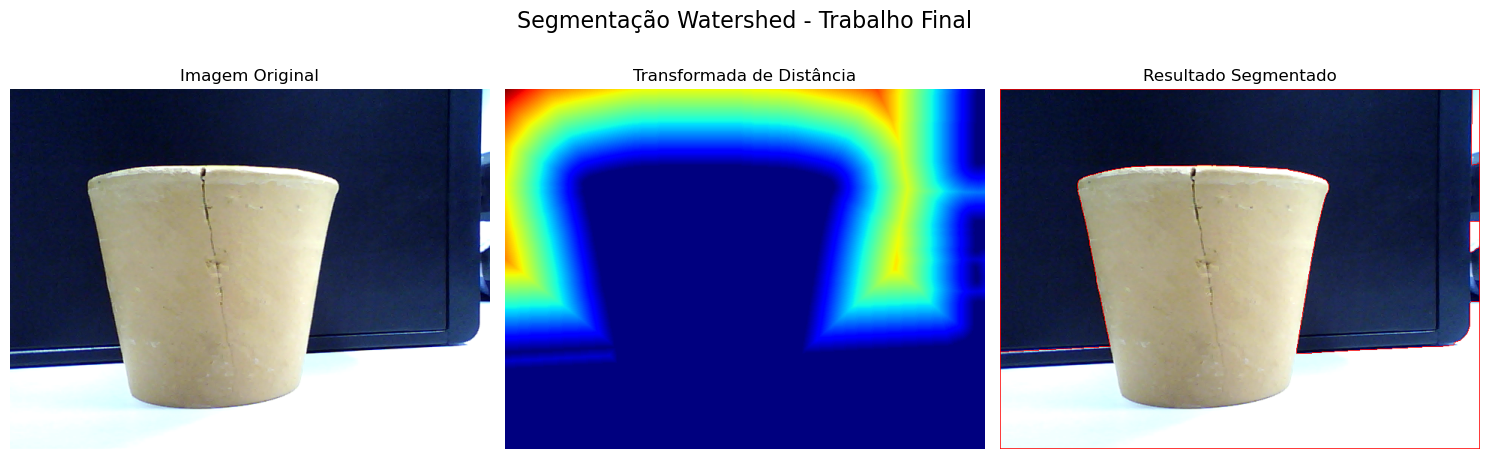

['avatar01.png', 'foto1.png', 'avatar02.png', 'avatar.png', 'Untitled.ipynb', 'minha_foto.png', 'foto_equipe.png', 'Gravação de tela de 2026-04-14 22-05-16.webm', '.ipynb_checkpoints']


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def watershed_trabalho_final(caminho_imagem):
    # 1. Carregamento da imagem (Forçando leitura em 3 canais - BGR)
    img = cv2.imread(caminho_imagem, cv2.IMREAD_COLOR)
    
    if img is None:
        print(f"ERRO: O Python não encontrou o arquivo '{caminho_imagem}'!")
        print("Verifique se o nome está correto e se a foto está na mesma pasta do código.")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Remoção de Ruído
    suave = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # 3. Limiarização
    ret, thresh = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Morfologia Matemática
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # 5. Transformada de Distância
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # 6. Região desconhecida e Rotulação
    unknown = cv2.subtract(sure_bg, sure_fg)
    ret, markers = cv2.connectedComponents(sure_fg)
    
    markers = markers + 1
    markers[unknown == 255] = 0

    # 7. Aplicação do Watershed
    markers = cv2.watershed(img, markers)
    
    # Pintando os contornos encontrados de vermelho (255, 0, 0)
    img_resultado = img_rgb.copy()
    img_resultado[markers == -1] = [255, 0, 0]

    # --- Plotagem ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Segmentação Watershed - Trabalho Final', fontsize=16)

    axes[0].imshow(img_rgb)
    axes[0].set_title('Imagem Original')
    axes[0].axis('off')
    
    axes[1].imshow(dist_transform, cmap='jet')
    axes[1].set_title('Transformada de Distância')
    axes[1].axis('off')
    
    axes[2].imshow(img_resultado)
    axes[2].set_title('Resultado Segmentado')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Conclusões 

A prática evidenciou que o Watershed funciona muito bem para isolar os elementos de interesse quando temos controle da iluminação e dos parâmetros, como vimos nas fotos da equipe e nas imagens estáticas do projeto final. No entanto, a implementação em tempo real na webcam mostrou que o método é extremamente sensível a variações dinâmicas na cena, gerando oscilações e falhas de rotulação devido à dependência direta da transformada de distância e da limiarização inicial. Isso deixa claro que o uso dessa técnica de segmentação morfológica, especialmente se levada para o escopo definitivo da nossa aplicação, vai exigir um pré-processamento mais robusto para estabilizar o contraste e lidar com os ruídos do ambiente antes que a "água" do algoritmo comece a preencher as regiões.

# Referências

- [Tutorial Watershed: Image Segmentation with Watershed Algorithm](https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html)
- [Tutorial Limiarização: Image Thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)
- [Image Thresholding in OpenCV](https://learnopencv.com/opencv-threshold-python-cpp/)